In [1]:
#setup environment
!pip install pandas numpy matplotlib seaborn wordcloud

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [8]:
airbnb_df = pd.read_csv(
    '/content/drive/MyDrive/Portfolio/Airbnb/nyc-airbnb-2023.csv',
    dtype={'license': 'string'},
    low_memory=False
)

airbnb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42931 entries, 0 to 42930
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              42931 non-null  int64  
 1   name                            42919 non-null  object 
 2   host_id                         42931 non-null  int64  
 3   host_name                       42926 non-null  object 
 4   neighbourhood_group             42931 non-null  object 
 5   neighbourhood                   42931 non-null  object 
 6   latitude                        42931 non-null  float64
 7   longitude                       42931 non-null  float64
 8   room_type                       42931 non-null  object 
 9   price                           42931 non-null  int64  
 10  minimum_nights                  42931 non-null  int64  
 11  number_of_reviews               42931 non-null  int64  
 12  last_review                     

In [9]:
text_cols = ['name', 'host_name']
airbnb_df[text_cols] = airbnb_df[text_cols].astype('string')

In [10]:
cat_cols = ['neighbourhood_group', 'neighbourhood', 'room_type']
airbnb_df[cat_cols] = airbnb_df[cat_cols].astype('category')

In [11]:
airbnb_df['last_review'] = pd.to_datetime(
    airbnb_df['last_review'],
    errors='coerce'
)

In [12]:
airbnb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42931 entries, 0 to 42930
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              42931 non-null  int64         
 1   name                            42919 non-null  string        
 2   host_id                         42931 non-null  int64         
 3   host_name                       42926 non-null  string        
 4   neighbourhood_group             42931 non-null  category      
 5   neighbourhood                   42931 non-null  category      
 6   latitude                        42931 non-null  float64       
 7   longitude                       42931 non-null  float64       
 8   room_type                       42931 non-null  category      
 9   price                           42931 non-null  int64         
 10  minimum_nights                  42931 non-null  int64         
 11  nu

In [13]:
airbnb_df['neighbourhood'] = (
    airbnb_df['neighbourhood']
    .str.strip()
    .str.title()
)

In [14]:
airbnb_df.isna().mean().sort_values(ascending=False)

,0
license,0.999977
reviews_per_month,0.240013
last_review,0.240013
name,0.000280
host_name,0.000116
id,0.000000
latitude,0.000000
host_id,0.000000
neighbourhood_group,0.000000
neighbourhood,0.000000


In [15]:
airbnb_df = airbnb_df.drop(columns=['license'])

In [16]:
airbnb_df['has_reviews'] = airbnb_df['last_review'].notna()

In [17]:
reference_date = airbnb_df['last_review'].max()
airbnb_df['days_since_last_review'] = (
    reference_date - airbnb_df['last_review']
).dt.days

In [18]:
airbnb_df['reviews_per_month'] = airbnb_df['reviews_per_month'].fillna(0)

In [19]:
airbnb_df['name'] = airbnb_df['name'].fillna('Unknown')
airbnb_df['host_name'] = airbnb_df['host_name'].fillna('Unknown')

In [20]:
airbnb_df.isna().mean().sort_values(ascending=False)

,0
days_since_last_review,0.240013
last_review,0.240013
id,0.000000
host_id,0.000000
name,0.000000
host_name,0.000000
neighbourhood_group,0.000000
longitude,0.000000
room_type,0.000000
neighbourhood,0.000000


In [22]:
airbnb_df.groupby(
    'neighbourhood_group',
    observed=True
)['price'].describe()

,count,mean,std,min,25%,50%,75%,max
neighbourhood_group,,,,,,,,
Bronx,1691.0,117.512123,262.810878,0.0,58.0,87.0,133.0,9994.0
Brooklyn,16237.0,162.766829,1043.120669,0.0,66.0,110.0,179.0,99000.0
Manhattan,17658.0,268.365783,807.318180,0.0,101.0,165.0,272.0,85100.0
Queens,6916.0,128.173655,307.745972,10.0,57.0,90.0,144.0,10000.0
Staten Island,429.0,309.037296,3166.281483,26.0,70.0,99.0,140.0,65115.0


In [23]:
airbnb_df.groupby(
    'neighbourhood_group',
    observed=True
)['price'].median().sort_values(ascending=False)

,price
neighbourhood_group,
Manhattan,165.0
Brooklyn,110.0
Staten Island,99.0
Queens,90.0
Bronx,87.0


In [24]:
airbnb_df.groupby(
    'room_type',
    observed=True
)['price'].median().sort_values(ascending=False)

,price
room_type,
Hotel room,240.0
Entire home/apt,174.0
Private room,73.0
Shared room,56.5


In [25]:
airbnb_df.groupby(
    'has_reviews',
    observed=True
)['price'].median()

,price
has_reviews,
False,137.0
True,123.0


In [26]:
hero_df = (
    airbnb_df
    .groupby(
        ['neighbourhood_group', 'room_type'],
        observed=True
    )['price']
    .median()
    .reset_index()
)

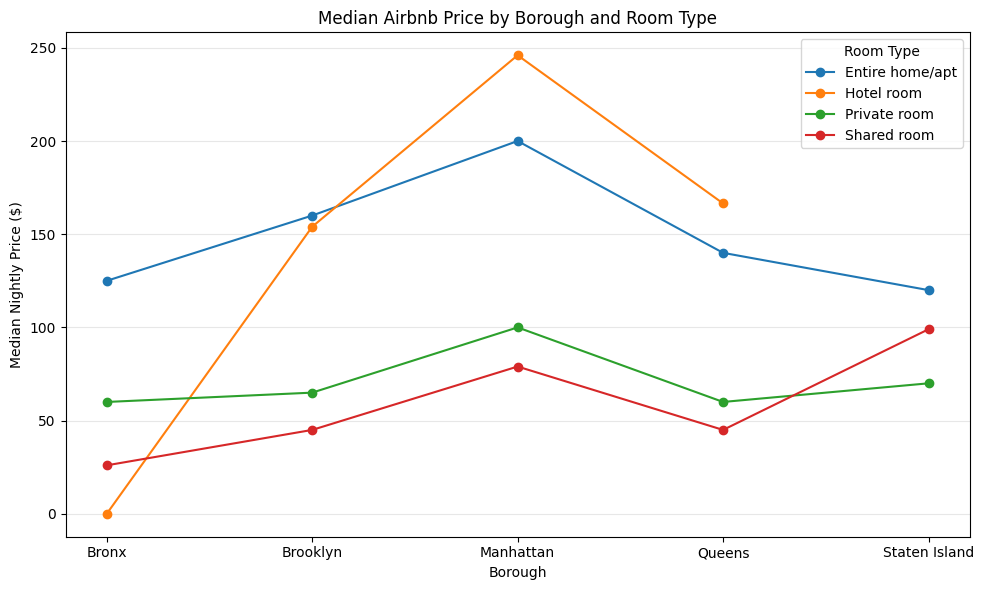

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for room_type in hero_df['room_type'].unique():
    subset = hero_df[hero_df['room_type'] == room_type]
    plt.plot(
        subset['neighbourhood_group'],
        subset['price'],
        marker='o',
        label=room_type
    )

plt.title('Median Airbnb Price by Borough and Room Type')
plt.xlabel('Borough')
plt.ylabel('Median Nightly Price ($)')
plt.legend(title='Room Type')
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Median nightly prices vary strongly by both borough and room type. Manhattan consistently commands the highest prices, while entire-home listings maintain a clear premium across all locations.

In [28]:
model_df = airbnb_df[
    ['price', 'has_reviews', 'neighbourhood_group', 'room_type']
].dropna()

In [29]:
X = pd.get_dummies(
    model_df[['has_reviews', 'neighbourhood_group', 'room_type']],
    drop_first=True
)

y = model_df['price']

In [30]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [31]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_
}).sort_values(by='coefficient')

coef_df

,feature,coefficient
7,room_type_Shared room,-115.559948
6,room_type_Private room,-104.980077
0,has_reviews,-79.711745
3,neighbourhood_group_Queens,10.805626
5,room_type_Hotel room,20.041032
1,neighbourhood_group_Brooklyn,34.648014
2,neighbourhood_group_Manhattan,122.992413
4,neighbourhood_group_Staten Island,181.791603


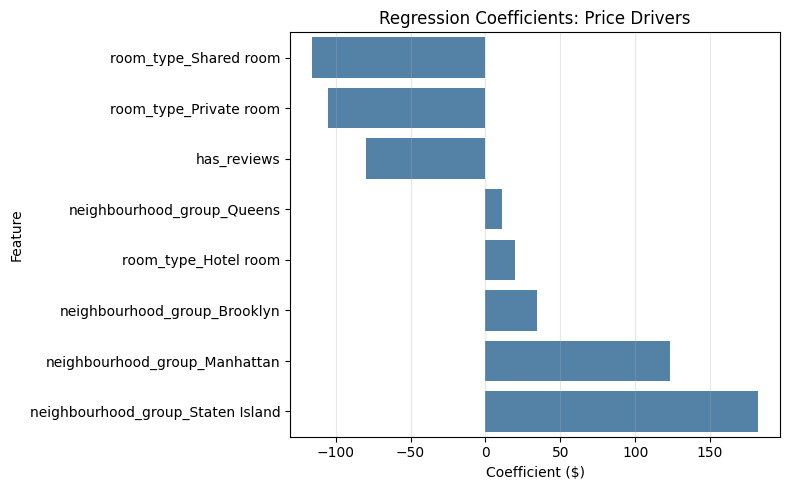

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(
    x='coefficient',
    y='feature',
    data=coef_plot,
    color='steelblue'
)
plt.title('Regression Coefficients: Price Drivers')
plt.xlabel('Coefficient ($)')
plt.ylabel('Feature')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()